In [1]:
# Compute the deterministic scores

# NOTE: To be simplified. Some functions will change a bit.

import numpy as np
import xarray as xr
import cartopy.io.shapereader as shpreader
from cartopy.feature import ShapelyFeature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

import load_daily_mean_data as ldmd
import data_utils as du

In [9]:
import os
# Laptop
IMERG_simplified_data_dir = "./IMERG/"
cGAN_forecast_data_dir = "./cGAN/"

shapefile_name = "../SEWAA-forecasts-main/shapes/Ethiopia_shapes/Ethiopia_region.shp"
deterministic_metrics_output_dir = "./Deterministic_comparison/"
if not os.path.exists(deterministic_metrics_output_dir):
    os.makedirs(deterministic_metrics_output_dir)

# Number of forecast lead days
num_lead_days = 1

# The month to consider
year = 2025
month = 6

In [3]:
# Load daily mean IMERG data for one month
daily_precip_IMERG = ldmd.load_daily_mean_IMERG_by_month_simplified(
    year=year,
    month=month,
    data_dir=IMERG_simplified_data_dir,
)


/Users/nath/Documents/cGAN_verification/load_daily_mean_data.py:295: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  nc_file = xr.open_mfdataset(files).sortby('time')


In [4]:
# Load the GAN forecasts for 1 day so far computed.
daily_precip_cGAN, valid_times = ldmd.load_daily_mean_cGAN_by_month(year=year,
                                                       month=month,
                                                       data_dir=cGAN_forecast_data_dir,
                                                       lead_time_offset=30,
                                                       num_lead_days=num_lead_days,
                                                       full_day_data=True,
                                                       latitude=daily_precip_IMERG.latitude.values,
                                                       longitude=daily_precip_IMERG.longitude.values)


In [5]:
# daily_precip_KMD_WRF = ldmd.load_daily_mean_KMD_WRF_by_month(
#     year=year,              # Year to load
#     month=month,            # Month to load (1-12)
#     data_dir=KMD_data_dir,  # Where the data is stored
#     num_lead_days=2,        # Number of forecast lead days to load
#     lead_time_offset=6,    # Hours since 00:00 UTC before the first lead time
#     latitude=latitude,      # List of latitudes to load (None means load all)
#     longitude=longitude,    # List of longitudes to load (None means load all)
#     mask=mask               # A mask: True where data is missing, False otherwise
# )

In [5]:
daily_precip_IMERG

<xarray.DataArray (time: 29, latitude: 384, longitude: 352)> Size: 16MB
array([[[0.        , 0.        , 0.        , ..., 3.6249998 ,
         3.365     , 3.2149997 ],
        [0.        , 0.        , 0.        , ..., 3.7799997 ,
         3.92      , 4.085     ],
        [0.        , 0.        , 0.        , ..., 3.435     ,
         3.3599997 , 3.305     ],
        ...,
        [0.39499998, 0.045     , 0.13499999, ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.515     , 0.175     , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.015     , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.145     ,
         0.13499999, 0.08      ],
        [0.        , 0.        , 0.        , ..., 0.09999999,
         0.19      , 0.075     ],
        [0.        , 0.        , 0.        , ..., 0.16      ,
         0.16499999, 0.055     ],
...
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]],

       [[0.        , 0.        , 0.        , ..., 0.015     ,
         0.04      , 0.095     ],
        [0.        , 0.        , 0.        , ..., 0.10499999,
         0.21000001, 0.22000001],
        [0.        , 0.        , 0.        , ..., 0.195     ,
         0.26999998, 0.32      ],
        ...,
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ]]], shape=(29, 384, 352), dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 232B 2025-06-01T06:00:00 ... 2025-06-29T...
  * latitude   (latitude) float32 2kB -13.65 -13.55 -13.45 ... 24.45 24.55 24.65
  * longitude  (longitude) float32 1kB 19.15 19.25 19.35 ... 54.05 54.15 54.25

In [6]:
daily_precip_cGAN = xr.DataArray(daily_precip_cGAN[:,0], dims=['time','latitude','longitude'],
                                 coords={\
                                 'time':[datetime(1900,1,1) + timedelta(hours=int(v)) for v in valid_times[:,0]],
                                 'latitude':daily_precip_IMERG.latitude.values,
                                 'longitude':daily_precip_IMERG.longitude.values})

In [7]:
daily_precip_cGAN

<xarray.DataArray (time: 1, latitude: 384, longitude: 352)> Size: 1MB
array([[[3.81439745e-01, 2.61045516e-01, 2.18669087e-01, ...,
         7.66336262e-01, 9.14348722e-01, 1.09149730e+00],
        [3.04227203e-01, 2.23108947e-01, 2.00218186e-01, ...,
         5.81626773e-01, 7.35436797e-01, 8.75666678e-01],
        [2.33847007e-01, 1.68363407e-01, 1.46242082e-01, ...,
         5.32775640e-01, 6.48637831e-01, 7.92425632e-01],
        ...,
        [6.89059377e-01, 4.15626109e-01, 2.76627094e-01, ...,
         3.36393365e-04, 5.99189778e-04, 6.56630495e-04],
        [9.02839184e-01, 5.54622173e-01, 3.85329008e-01, ...,
         7.22188037e-04, 8.35218409e-04, 1.36671925e-03],
        [1.00263739e+00, 6.39285982e-01, 4.11684036e-01, ...,
         2.03644755e-04, 4.97097033e-04, 9.25080269e-04]]],
      shape=(1, 384, 352))
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-06-02T06:00:00
  * latitude   (latitude) float32 2kB -13.65 -13.55 -13.45 ... 24.45 24.55 24.65
  * longitude  (longitude) float32 1kB 19.15 19.25 19.35 ... 54.05 54.15 54.25

## Extract Ethiopia Region

In [10]:
import shapefile
from shapely.geometry.polygon import Polygon
import regionmask
from shapely.ops import unary_union

sf_region_ETH = shapefile.Reader(shapefile_name)
features = sf_region_ETH.shapeRecords()
Locations_ETH = np.array([feat.record[4] for feat in features])

In [11]:
Locations_ETH

array(['Addis Ababa', 'Afar', 'Amhara', 'Benshangul-Gumaz', 'Dire Dawa',
       'Gambela Peoples', 'Harari People', 'Oromia', 'Somali',
       'Southern Nations, Nationalities and Peoples', 'Tigray'],
      dtype='<U43')

In [12]:
Locations = ['Addis Ababa', 'Afar', 'Amhara', 'Benshangul-Gumaz', 'Dire Dawa',
             'Gambela Peoples', 'Harari People', 'Oromia', 'Somali',
             'Southern Nations, Nationalities and Peoples', 'Tigray']

geometry_all_county = [Polygon(sf_region_ETH.shape(i).points) for i in range(len(Locations_ETH)) if\
                                          Locations_ETH[i] in Locations]

sf_region = shapefile.Reader(shpreader.natural_earth(resolution='110m',
                                              category='cultural',
                                              name='admin_0_countries'))
features = sf_region.shapeRecords()
geometry_all = [Polygon(sf_region.shape(i).points)  for i in range(len(features)) if features[i].record[3] in ['Ethiopia']]


region_vectorised = regionmask.Regions(geometry_all,overlap=False)
mask_list = region_vectorised.mask_3D(daily_precip_IMERG.rename({'longitude':'lon','latitude':'lat'}))




# Get metrics

In [14]:
def mae(x,y):
    return np.abs(x-y)

def rmse(x,y):
    return (x-y)**2

mae = xr.apply_ufunc(mae,
                    daily_precip_IMERG.sel({'time':daily_precip_cGAN.time.values}).compute(),
                    daily_precip_cGAN).mean('time').rename('mae')
rmse =  np.sqrt(xr.apply_ufunc(rmse,
                    daily_precip_IMERG.sel({'time':daily_precip_cGAN.time.values}).compute(),
                    daily_precip_cGAN).mean('time')).rename('rmse')

ds_metrics = xr.merge([mae,rmse])


In [15]:
ds_metrics

<xarray.Dataset> Size: 2MB
Dimensions:    (latitude: 384, longitude: 352)
Coordinates:
  * latitude   (latitude) float32 2kB -13.65 -13.55 -13.45 ... 24.45 24.55 24.65
  * longitude  (longitude) float32 1kB 19.15 19.25 19.35 ... 54.05 54.15 54.25
Data variables:
    mae        (latitude, longitude) float64 1MB 0.3814 0.261 ... 0.0009251
    rmse       (latitude, longitude) float64 1MB 0.3814 0.261 ... 0.0009251

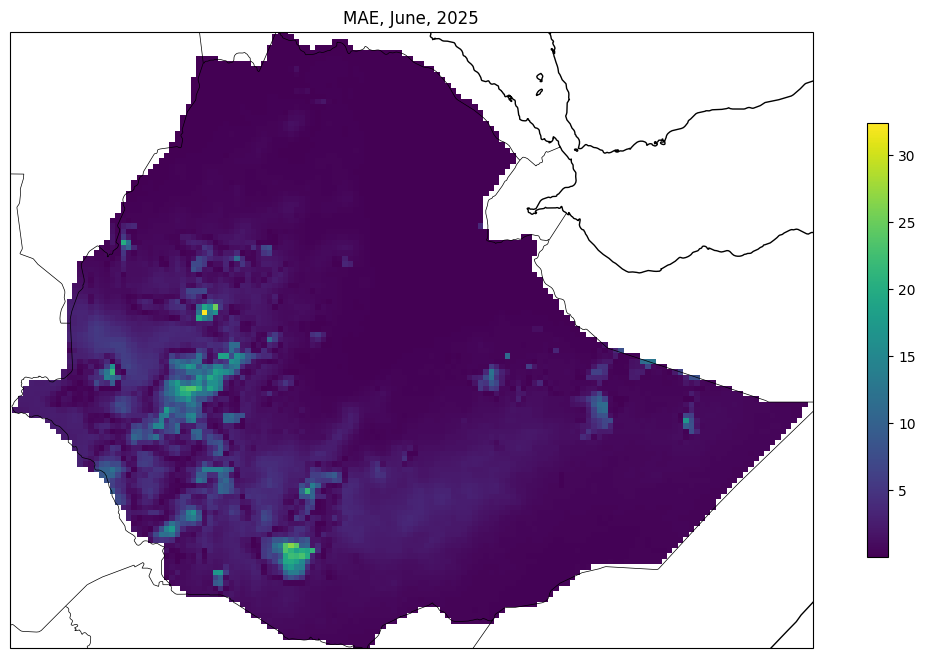

In [16]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

bounding_box = {'Ethiopia':(32.95418, 47.78942, 3.45, 14.837),'Kenya':(33.935689697, 41.5550830926, -4.559, 5.4877),
                'Rwanda':(28.87, 30.90, -2.81, -1.151)}
region_extent = bounding_box['Ethiopia']
months = ['Jan','Feb','March','April','May','June','July','Aug','Sept','Oct','Nov','Dec']

lons = ds_metrics.longitude.values
lats = ds_metrics.latitude.values

fig = plt.figure(figsize=(14,8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
d = np.full([len(lats),len(lons)],np.nan)
for m in mask_list:
    m = np.ma.masked_invalid(m)
    d[m] = ds_metrics.mae.values[m]

c = plt.pcolormesh(lons, lats, d,
                   transform=ccrs.PlateCarree(), cmap='viridis')

cb = plt.colorbar(c, fraction=0.02)

ax.set_title(f'MAE, {months[month-1]}, {year}')
ax.set_extent([region_extent[0],region_extent[1],
               region_extent[2],region_extent[3]], crs=ccrs.PlateCarree())